# Nail Disease Training Notebook (Colab)

This notebook trains on **combined_dataset_balanced** using transfer learning and fine-tuning.
It also supports multi-model comparison and optional ensembling.

## Goal
- Maximize validation accuracy (target: 90%+)
- Keep macro performance strong across all classes

## Recommended training mechanism
1. Transfer learning with ImageNet backbones
2. Stage-1: frozen backbone warm-up
3. Stage-2: partial unfreeze fine-tuning at lower LR
4. Class-weighted loss to address class imbalance
5. Early stopping + best-checkpoint restore
6. Optional model sweep + ensemble

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# If needed in fresh Colab runtime
!pip -q install -U scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 17.9 MB/s eta 0:00:00


In [4]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

print('TensorFlow:', tf.__version__)

TensorFlow: 2.19.0


## Dataset Setup
Use one of the options below:
- Option A: dataset in Google Drive
- Option B: upload zip and extract to /content

In [5]:
# ---------- CONFIG ----------
USE_DRIVE = True
DRIVE_DATASET_DIR = '/content/drive/MyDrive/combined_dataset_balanced'
ZIP_PATH = '/content/combined_dataset_balanced.zip'
EXTRACT_TO = '/content'

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    DATASET_DIR = Path(DRIVE_DATASET_DIR)
else:
    DATASET_DIR = Path('/content/combined_dataset_balanced')
    if not DATASET_DIR.exists() and Path(ZIP_PATH).exists():
        import zipfile
        with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
            zf.extractall(EXTRACT_TO)

assert DATASET_DIR.exists(), f'Dataset not found: {DATASET_DIR}'
assert (DATASET_DIR / 'train').exists(), 'train folder missing'
assert (DATASET_DIR / 'validation').exists(), 'validation folder missing'

print('Using dataset at:', DATASET_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using dataset at: /content/drive/MyDrive/combined_dataset_balanced


In [6]:
def count_images(split_dir):
    split_dir = Path(split_dir)
    counts = {}
    for cls in sorted([d for d in split_dir.iterdir() if d.is_dir()]):
        n = len([f for f in cls.rglob('*') if f.is_file()])
        counts[cls.name] = n
    return pd.Series(counts).sort_index()

train_counts = count_images(DATASET_DIR / 'train')
val_counts = count_images(DATASET_DIR / 'validation')

display(pd.DataFrame({'train': train_counts, 'validation': val_counts}))
print('Total train:', int(train_counts.sum()))
print('Total validation:', int(val_counts.sum()))

,train,validation
Acral_Lentiginous_Melanoma,735,18
Healthy_Nail,323,20
Nail_psoriasis,700,100
Onychogryphosis,677,12
blue_finger,603,9
clubbing,767,16
pitting,639,16


Total train: 4444
Total validation: 191


In [7]:
# ---------- TRAINING CONFIG ----------
BATCH_SIZE = 32
EPOCHS_WARMUP = 8
EPOCHS_FINETUNE = 14
BASE_LR_WARMUP = 1e-3
BASE_LR_FINETUNE = 1e-4
LABEL_SMOOTHING = 0.05
FINE_TUNE_RATIO = 0.3  # Unfreeze top 30% of backbone

TRAIN_ALL_MODELS = True   # set False for fastest single-model run
SINGLE_MODEL_NAME = 'EfficientNetB0'

AUTOTUNE = tf.data.AUTOTUNE

In [8]:
MODEL_ZOO = {
    'EfficientNetB0': {
        'constructor': tf.keras.applications.EfficientNetB0,
        'preprocess': tf.keras.applications.efficientnet.preprocess_input,
        'img_size': 224
    },
    'MobileNetV3Large': {
        'constructor': tf.keras.applications.MobileNetV3Large,
        'preprocess': tf.keras.applications.mobilenet_v3.preprocess_input,
        'img_size': 224
    },
    'ResNet50': {
        'constructor': tf.keras.applications.ResNet50,
        'preprocess': tf.keras.applications.resnet50.preprocess_input,
        'img_size': 224
    }
}

def make_datasets(img_size):
    train_ds = tf.keras.utils.image_dataset_from_directory(
        DATASET_DIR / 'train',
        labels='inferred',
        label_mode='int',
        image_size=(img_size, img_size),
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=SEED
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        DATASET_DIR / 'validation',
        labels='inferred',
        label_mode='int',
        image_size=(img_size, img_size),
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    class_names = train_ds.class_names
    return train_ds, val_ds, class_names

augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.2),
], name='augment')

In [9]:
def get_class_weights_from_train_dir(class_names):
    y = []
    class_to_idx = {c: i for i, c in enumerate(class_names)}
    for c in class_names:
        cls_dir = DATASET_DIR / 'train' / c
        n = len([f for f in cls_dir.rglob('*') if f.is_file()])
        y.extend([class_to_idx[c]] * n)

    weights = compute_class_weight(
        class_weight='balanced',
        classes=np.arange(len(class_names)),
        y=np.array(y)
    )
    return {i: float(w) for i, w in enumerate(weights)}

def build_model(backbone_name, num_classes):
    cfg = MODEL_ZOO[backbone_name]
    img_size = cfg['img_size']
    preprocess = cfg['preprocess']

    inputs = tf.keras.Input(shape=(img_size, img_size, 3))
    x = augment(inputs)
    x = preprocess(x)

    base = cfg['constructor'](
        include_top=False,
        weights='imagenet',
        input_shape=(img_size, img_size, 3)
    )
    base.trainable = False

    x = base(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs, name=f'{backbone_name}_classifier')
    return model, base

def unfreeze_top_layers(base, ratio=0.3):
    base.trainable = True
    n = len(base.layers)
    freeze_until = int(n * (1 - ratio))

    for i, layer in enumerate(base.layers):
        # Keep BatchNorm frozen for stable fine-tuning
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = i >= freeze_until

In [15]:
def evaluate_model(model, val_ds, class_names):
    y_true = []
    y_prob = []

    for xb, yb in val_ds:
        p = model.predict(xb, verbose=0)
        y_true.extend(yb.numpy().tolist())
        y_prob.extend(p.tolist())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = np.argmax(y_prob, axis=1)

    acc = accuracy_score(y_true, y_pred)
    print(f'Validation accuracy: {acc:.4f}')
    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 6))
    plt.imshow(cm, cmap='Blues')
    plt.title('Confusion Matrix')
    plt.colorbar()
    plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
    plt.yticks(range(len(class_names)), class_names)
    plt.tight_layout()
    plt.show()

    return acc, y_true, y_prob

def train_one_model(backbone_name):
    print(f'\n===== Training {backbone_name} =====')
    cfg = MODEL_ZOO[backbone_name]
    img_size = cfg['img_size']

    train_ds, val_ds, class_names = make_datasets(img_size)
    class_weights = get_class_weights_from_train_dir(class_names)

    train_ds = train_ds.prefetch(AUTOTUNE)
    val_ds = val_ds.prefetch(AUTOTUNE)

    model, base = build_model(backbone_name, num_classes=len(class_names))

    ckpt_path = f'/content/best_{backbone_name}.keras'
    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            ckpt_path,
            monitor='val_accuracy',
            save_best_only=True,
            mode='max'
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=4,
            mode='max',
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.3,
            patience=2,
            verbose=1
        ),
    ]

    # Stage-1: warm-up with frozen backbone
    model.compile(
        optimizer=tf.keras.optimizers.Adam(BASE_LR_WARMUP),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy']
    )

    history_warmup = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_WARMUP,
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1
    )

    # Stage-2: fine-tuning
    unfreeze_top_layers(base, ratio=FINE_TUNE_RATIO)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(BASE_LR_FINETUNE),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy']
    )

    history_ft = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_FINETUNE,
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1
    )

    # Reload best checkpoint for final eval
    model = tf.keras.models.load_model(ckpt_path)
    val_acc, y_true, y_prob = evaluate_model(model, val_ds, class_names)

    return {
        'name': backbone_name,
        'val_accuracy': val_acc,
        'model_path': ckpt_path,
        'class_names': class_names,
        'y_true': y_true,
        'y_prob': y_prob,
        'history_warmup': history_warmup.history,
        'history_finetune': history_ft.history,
    }


===== Training EfficientNetB0 =====
Found 4444 files belonging to 7 classes.
Found 191 files belonging to 7 classes.
Epoch 1/8
139/139 ━━━━━━━━━━━━━━━━━━━━ 730s 5s/step - accuracy: 0.6274 - loss: 1.0136 - val_accuracy: 0.9058 - val_loss: 0.3913 - learning_rate: 0.0010
Epoch 2/8
139/139 ━━━━━━━━━━━━━━━━━━━━ 21s 151ms/step - accuracy: 0.7979 - loss: 0.5743 - val_accuracy: 0.9058 - val_loss: 0.3066 - learning_rate: 0.0010
Epoch 3/8
139/139 ━━━━━━━━━━━━━━━━━━━━ 22s 159ms/step - accuracy: 0.8180 - loss: 0.4926 - val_accuracy: 0.9058 - val_loss: 0.2963 - learning_rate: 0.0010
Epoch 4/8
139/139 ━━━━━━━━━━━━━━━━━━━━ 21s 149ms/step - accuracy: 0.8312 - loss: 0.4541 - val_accuracy: 0.9058 - val_loss: 0.2577 - learning_rate: 0.0010
Epoch 5/8
139/139 ━━━━━━━━━━━━━━━━━━━━ 22s 154ms/step - accuracy: 0.8456 - loss: 0.4247 - val_accuracy: 0.9058 - val_loss: 0.2640 - learning_rate: 0.0010
Epoch 1/14
139/139 ━━━━━━━━━━━━━━━━━━━━ 43s 190ms/step - accuracy: 0.8418 - loss: 0.4178 - val_accuracy: 0.9215 - 

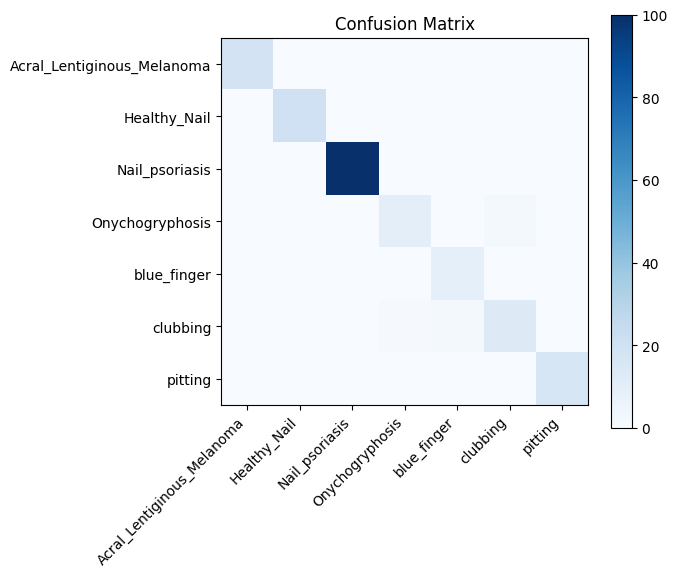


===== Training MobileNetV3Large =====
Found 4444 files belonging to 7 classes.
Found 191 files belonging to 7 classes.
12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/8
139/139 ━━━━━━━━━━━━━━━━━━━━ 34s 187ms/step - accuracy: 0.5767 - loss: 1.1386 - val_accuracy: 0.8848 - val_loss: 0.3487 - learning_rate: 0.0010
Epoch 2/8
139/139 ━━━━━━━━━━━━━━━━━━━━ 23s 162ms/step - accuracy: 0.7705 - loss: 0.6050 - val_accuracy: 0.9110 - val_loss: 0.2519 - learning_rate: 0.0010
Epoch 3/8
139/139 ━━━━━━━━━━━━━━━━━━━━ 21s 149ms/step - accuracy: 0.8083 - loss: 0.5015 - val_accuracy: 0.9267 - val_loss: 0.2485 - learning_rate: 0.0010
Epoch 4/8
139/139 ━━━━━━━━━━━━━━━━━━━━ 23s 161ms/step - accuracy: 0.8279 - loss: 0.4517 - val_accuracy: 0.9319 - val_loss: 0.2137 - learning_rate: 0.0010
Epoch 5/8
139/139 ━━━━━━━━━━━━━━━━━━━━ 40s 156ms/step - accuracy: 0.8443 - loss: 0.4192 - val_accuracy: 0.9319 - val_loss: 0.2133 - learning_rate: 0.0010
Epoch 6/8
139/139 ━━━━━━━━━━━━━━━━━━━━ 20s 145ms/step - acc

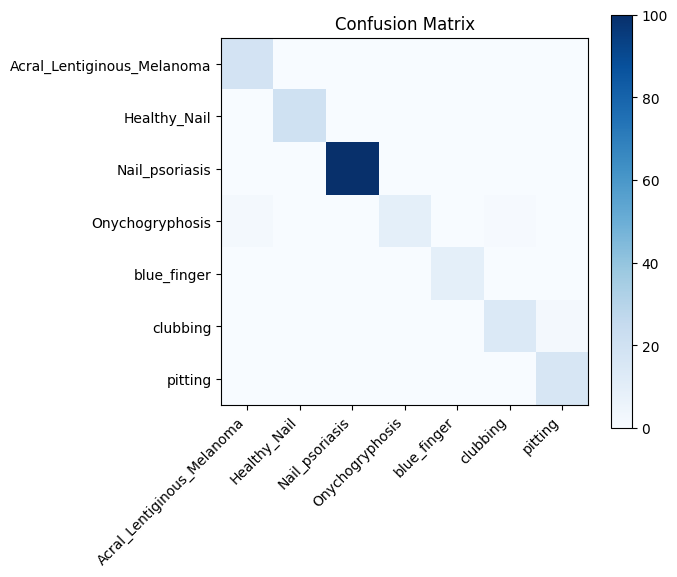


===== Training ResNet50 =====
Found 4444 files belonging to 7 classes.
Found 191 files belonging to 7 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/8
139/139 ━━━━━━━━━━━━━━━━━━━━ 36s 196ms/step - accuracy: 0.6546 - loss: 0.9206 - val_accuracy: 0.9476 - val_loss: 0.2235 - learning_rate: 0.0010
Epoch 2/8
139/139 ━━━━━━━━━━━━━━━━━━━━ 35s 159ms/step - accuracy: 0.7925 - loss: 0.5422 - val_accuracy: 0.9319 - val_loss: 0.1635 - learning_rate: 0.0010
Epoch 3/8
139/139 ━━━━━━━━━━━━━━━━━━━━ 23s 168ms/step - accuracy: 0.8207 - loss: 0.4602 - val_accuracy: 0.9581 - val_loss: 0.1274 - learning_rate: 0.0010
Epoch 4/8
139/139 ━━━━━━━━━━━━━━━━━━━━ 23s 165ms/step - accuracy: 0.8407 - loss: 0.4014 - val_accuracy: 0.9686 - val_loss: 0.1253 - learning_rate: 0.0010
Epoch 5/8
139/139 ━━━━━━━━━━━━━━━━━━━━ 23s 163ms/step - accuracy: 0.8513 - loss: 0.3779 - val_accuracy: 0.9372 - val_loss: 0.1503 - learning_rate: 0.0010
Epoch 6/8
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.

Validation accuracy: 0.9843

Classification Report:
                            precision    recall  f1-score   support

Acral_Lentiginous_Melanoma     1.0000    1.0000    1.0000        18
              Healthy_Nail     1.0000    1.0000    1.0000        20
            Nail_psoriasis     1.0000    1.0000    1.0000       100
           Onychogryphosis     0.9167    0.9167    0.9167        12
               blue_finger     1.0000    1.0000    1.0000         9
                  clubbing     0.9333    0.8750    0.9032        16
                   pitting     0.9412    1.0000    0.9697        16

                  accuracy                         0.9843       191
                 macro avg     0.9702    0.9702    0.9699       191
              weighted avg     0.9843    0.9843    0.9841       191



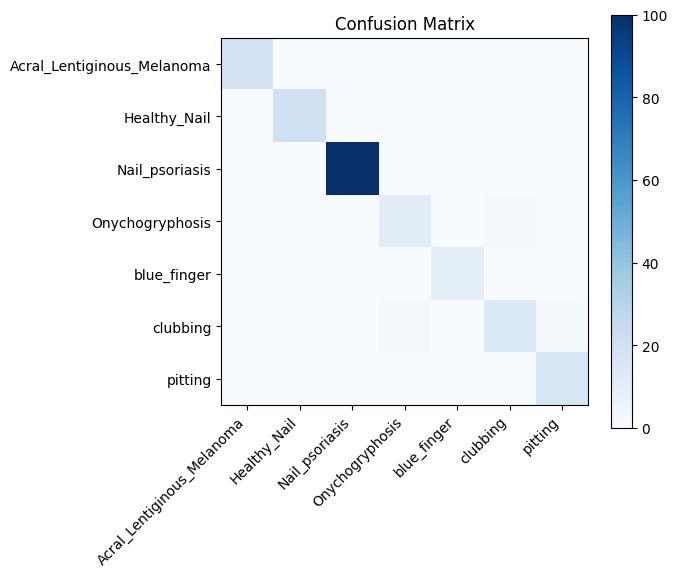

,model,val_accuracy
0,ResNet50,0.984293
1,EfficientNetB0,0.973822
2,MobileNetV3Large,0.973822


In [16]:
if TRAIN_ALL_MODELS:
    model_names = list(MODEL_ZOO.keys())
else:
    model_names = [SINGLE_MODEL_NAME]

results = []
for name in model_names:
    out = train_one_model(name)
    results.append(out)

summary = pd.DataFrame([{'model': r['name'], 'val_accuracy': r['val_accuracy']} for r in results])
summary = summary.sort_values('val_accuracy', ascending=False).reset_index(drop=True)
display(summary)

In [17]:
# Optional: simple average-probability ensemble of top-2 models
if len(results) >= 2:
    top2 = sorted(results, key=lambda x: x['val_accuracy'], reverse=True)[:2]

    y_true = top2[0]['y_true']
    avg_prob = (top2[0]['y_prob'] + top2[1]['y_prob']) / 2.0
    y_pred = np.argmax(avg_prob, axis=1)
    ens_acc = accuracy_score(y_true, y_pred)

    print('Top-2 models:', top2[0]['name'], 'and', top2[1]['name'])
    print(f'Ensemble validation accuracy: {ens_acc:.4f}')
    print('\nEnsemble classification report:')
    print(classification_report(y_true, y_pred, target_names=top2[0]['class_names'], digits=4))
else:
    print('Ensemble skipped (need at least 2 trained models).')

Top-2 models: ResNet50 and EfficientNetB0
Ensemble validation accuracy: 0.9843

Ensemble classification report:
                            precision    recall  f1-score   support

Acral_Lentiginous_Melanoma     1.0000    1.0000    1.0000        18
              Healthy_Nail     1.0000    1.0000    1.0000        20
            Nail_psoriasis     1.0000    1.0000    1.0000       100
           Onychogryphosis     0.9167    0.9167    0.9167        12
               blue_finger     1.0000    1.0000    1.0000         9
                  clubbing     0.9333    0.8750    0.9032        16
                   pitting     0.9412    1.0000    0.9697        16

                  accuracy                         0.9843       191
                 macro avg     0.9702    0.9702    0.9699       191
              weighted avg     0.9843    0.9843    0.9841       191



In [18]:
import shutil

# Define the destination on Drive
dest_dir = Path(DRIVE_DATASET_DIR) / 'trained_models'
os.makedirs(dest_dir, exist_ok=True)

# List of model paths from the results
for res in results:
    src = res['model_path']
    filename = os.path.basename(src)
    dst = dest_dir / filename

    print(f'Copying {filename} to {dest_dir}...')
    shutil.copy(src, dst)

print('\nAll models have been successfully saved to Google Drive.')

Copying best_EfficientNetB0.keras to /content/drive/MyDrive/combined_dataset_balanced/trained_models...
Copying best_MobileNetV3Large.keras to /content/drive/MyDrive/combined_dataset_balanced/trained_models...
Copying best_ResNet50.keras to /content/drive/MyDrive/combined_dataset_balanced/trained_models...

All models have been successfully saved to Google Drive.


## Notes for 90%+ target
- Start with EfficientNetB0 (usually strongest baseline for this type of image task).
- If validation plateaus below 90%, increase input size to 260 or 300 for EfficientNet variants.
- Keep class weights enabled and monitor macro metrics, not only overall accuracy.
- If one class underperforms, collect more real images for that class (most impactful improvement).